<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Hexaboron_Nitride_Electronic_Band_Structure_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

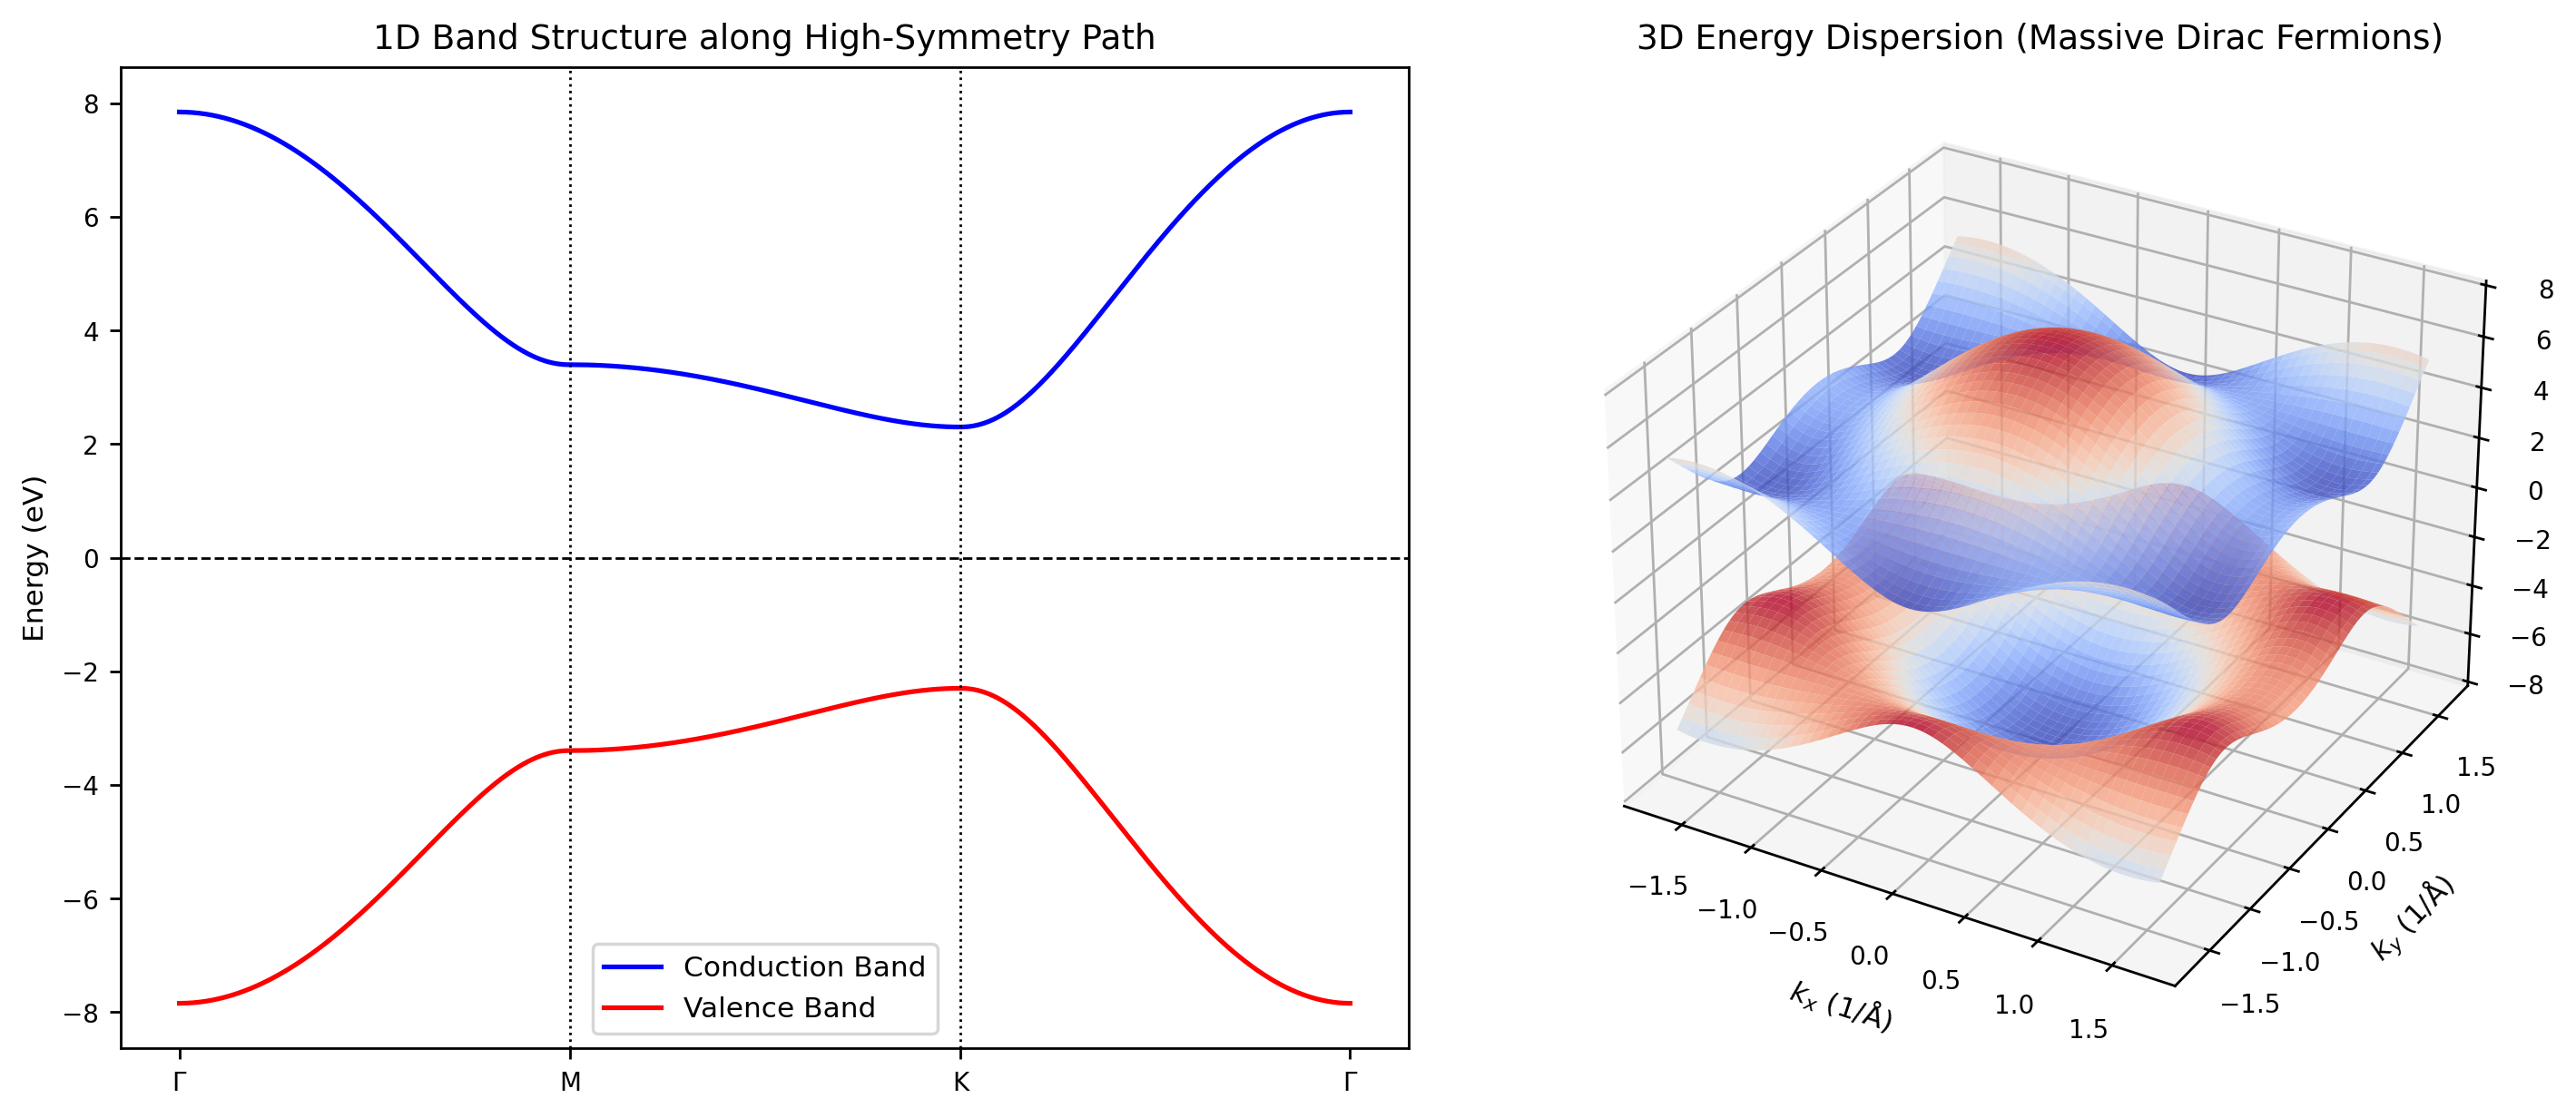

In [1]:
"""
Computes and visualizes the electronic band structure of hexagonal boron nitride.

This script evaluates the nearest-neighbor tight-binding Hamiltonian
for a pristine 2D hexagonal boron nitride lattice. It calculates and renders both the
1D energy dispersion along high-symmetry points in the Brillouin zone
and the 3D energy surface highlighting the massive Dirac fermions.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# =============================================================================
# CONTROL KNOBS
# =============================================================================
T_HOPPING: float = 2.5          # eV, nearest-neighbor hopping energy
DELTA_ONSITE: float = 4.6       # eV, on-site energy difference between B and N
A_LATTICE: float = 2.50         # Angstroms, lattice constant for h-BN
RES_1D: int = 300               # Resolution per segment for the 1D path
RES_2D: int = 150               # Resolution for the 2D surface mesh grid
PLOT_DPI: int = 250             # DPI for Colab inline rendering
FONT_SIZE: int = 9              # <--- ADJUST THIS to make all text smaller/larger

# =============================================================================
# Apply rendering preferences
# =============================================================================
plt.rcParams['figure.dpi'] = PLOT_DPI
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['font.size'] = FONT_SIZE  # Sets global font size for all elements

def calc_energy(k_x: np.ndarray, k_y: np.ndarray, t: float, delta: float, a: float) -> np.ndarray:
    """
    Calculates the tight-binding energy dispersion for hexagonal boron nitride.
    """
    # Evaluate the geometric structure factor modulus squared
    term1 = 4.0 * np.cos(np.sqrt(3.0) * k_x * a / 2.0) * np.cos(k_y * a / 2.0)
    term2 = 4.0 * np.cos(k_y * a / 2.0)**2
    f_k_squared = 1.0 + term1 + term2

    # Calculate the positive root representing the conduction band
    energy = np.sqrt((delta / 2.0)**2 + (t**2) * f_k_squared)
    return energy

def render_band_structure() -> None:
    """
    Generates and renders the 1D and 3D band structure plots.
    """
    fig = plt.figure(figsize=(12, 5))

    # ---------------------------------------------------------
    # 1. 1D High-Symmetry Path (Gamma -> M -> K -> Gamma)
    # ---------------------------------------------------------
    ax1 = fig.add_subplot(121)

    # High symmetry point coordinates in reciprocal space
    gamma = np.array([0.0, 0.0])
    m_point = np.array([2.0 * np.pi / (np.sqrt(3.0) * A_LATTICE), 0.0])
    k_point = np.array([2.0 * np.pi / (np.sqrt(3.0) * A_LATTICE), 2.0 * np.pi / (3.0 * A_LATTICE)])

    # Generate discrete linear segments between critical points
    path_g_m = np.linspace(gamma, m_point, RES_1D)
    path_m_k = np.linspace(m_point, k_point, RES_1D)
    path_k_g = np.linspace(k_point, gamma, RES_1D)

    # Aggregate the continuous coordinate vectors
    k_path = np.vstack((path_g_m, path_m_k, path_k_g))

    # Compute corresponding continuous band energies
    e_path_conduction = calc_energy(k_path[:, 0], k_path[:, 1], T_HOPPING, DELTA_ONSITE, A_LATTICE)
    e_path_valence = -e_path_conduction

    # Establish an ordered index array for mapping the sequential path
    x_axis = np.arange(len(k_path))
    m_idx = RES_1D
    k_idx = 2 * RES_1D

    ax1.plot(x_axis, e_path_conduction, color='b', label=r'Conduction Band')
    ax1.plot(x_axis, e_path_valence, color='r', label=r'Valence Band')

    # Apply precise stylistic formatting to the 1D plot
    ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax1.axvline(m_idx, color='k', linestyle=':', linewidth=0.8)
    ax1.axvline(k_idx, color='k', linestyle=':', linewidth=0.8)

    ax1.set_xticks([0, m_idx, k_idx, len(k_path) - 1])
    ax1.set_xticklabels([r'$\Gamma$', 'M', 'K', r'$\Gamma$'])
    ax1.set_ylabel("Energy (eV)")
    ax1.set_title("1D Band Structure along High-Symmetry Path")
    ax1.legend()
    ax1.tick_params(labelsize=FONT_SIZE - 1) # Slightly smaller ticks than labels
    ax1.grid(False)

    # ---------------------------------------------------------
    # 2. 3D Surface Plot of the Massive Dirac Fermions
    # ---------------------------------------------------------
    ax2 = fig.add_subplot(122, projection='3d')

    # Define Brillouin zone volumetric bounds
    k_extent = 4.0 * np.pi / (3.0 * A_LATTICE)
    kx_range = np.linspace(-k_extent, k_extent, RES_2D)
    ky_range = np.linspace(-k_extent, k_extent, RES_2D)
    kx_mesh, ky_mesh = np.meshgrid(kx_range, ky_range)

    # Compute expansive 2D energy topographies
    e_surface_conduction = calc_energy(kx_mesh, ky_mesh, T_HOPPING, DELTA_ONSITE, A_LATTICE)
    e_surface_valence = -e_surface_conduction

    # Render translucent three-dimensional surfaces
    surf1 = ax2.plot_surface(kx_mesh, ky_mesh, e_surface_conduction,
                             cmap=cm.coolwarm, alpha=0.8, antialiased=True)
    surf2 = ax2.plot_surface(kx_mesh, ky_mesh, e_surface_valence,
                             cmap=cm.coolwarm, alpha=0.8, antialiased=True)

    # Apply precise stylistic formatting to the 3D plot
    ax2.set_xlabel(r'$k_x$ (1/$\mathrm{\AA}$)')
    ax2.set_ylabel(r'$k_y$ (1/$\mathrm{\AA}$)')
    ax2.set_zlabel("Energy (eV)")
    ax2.set_title("3D Energy Dispersion (Massive Dirac Fermions)")
    ax2.tick_params(labelsize=FONT_SIZE - 1) # Slightly smaller ticks than labels

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_band_structure()

In [ ]:
# =============================================================================
# COLAB ENVIRONMENT SETUP
# Run this cell first to provision the T4 or other available GPU with the correct CuPy binary.
# =============================================================================
!pip install cupy-cuda12x

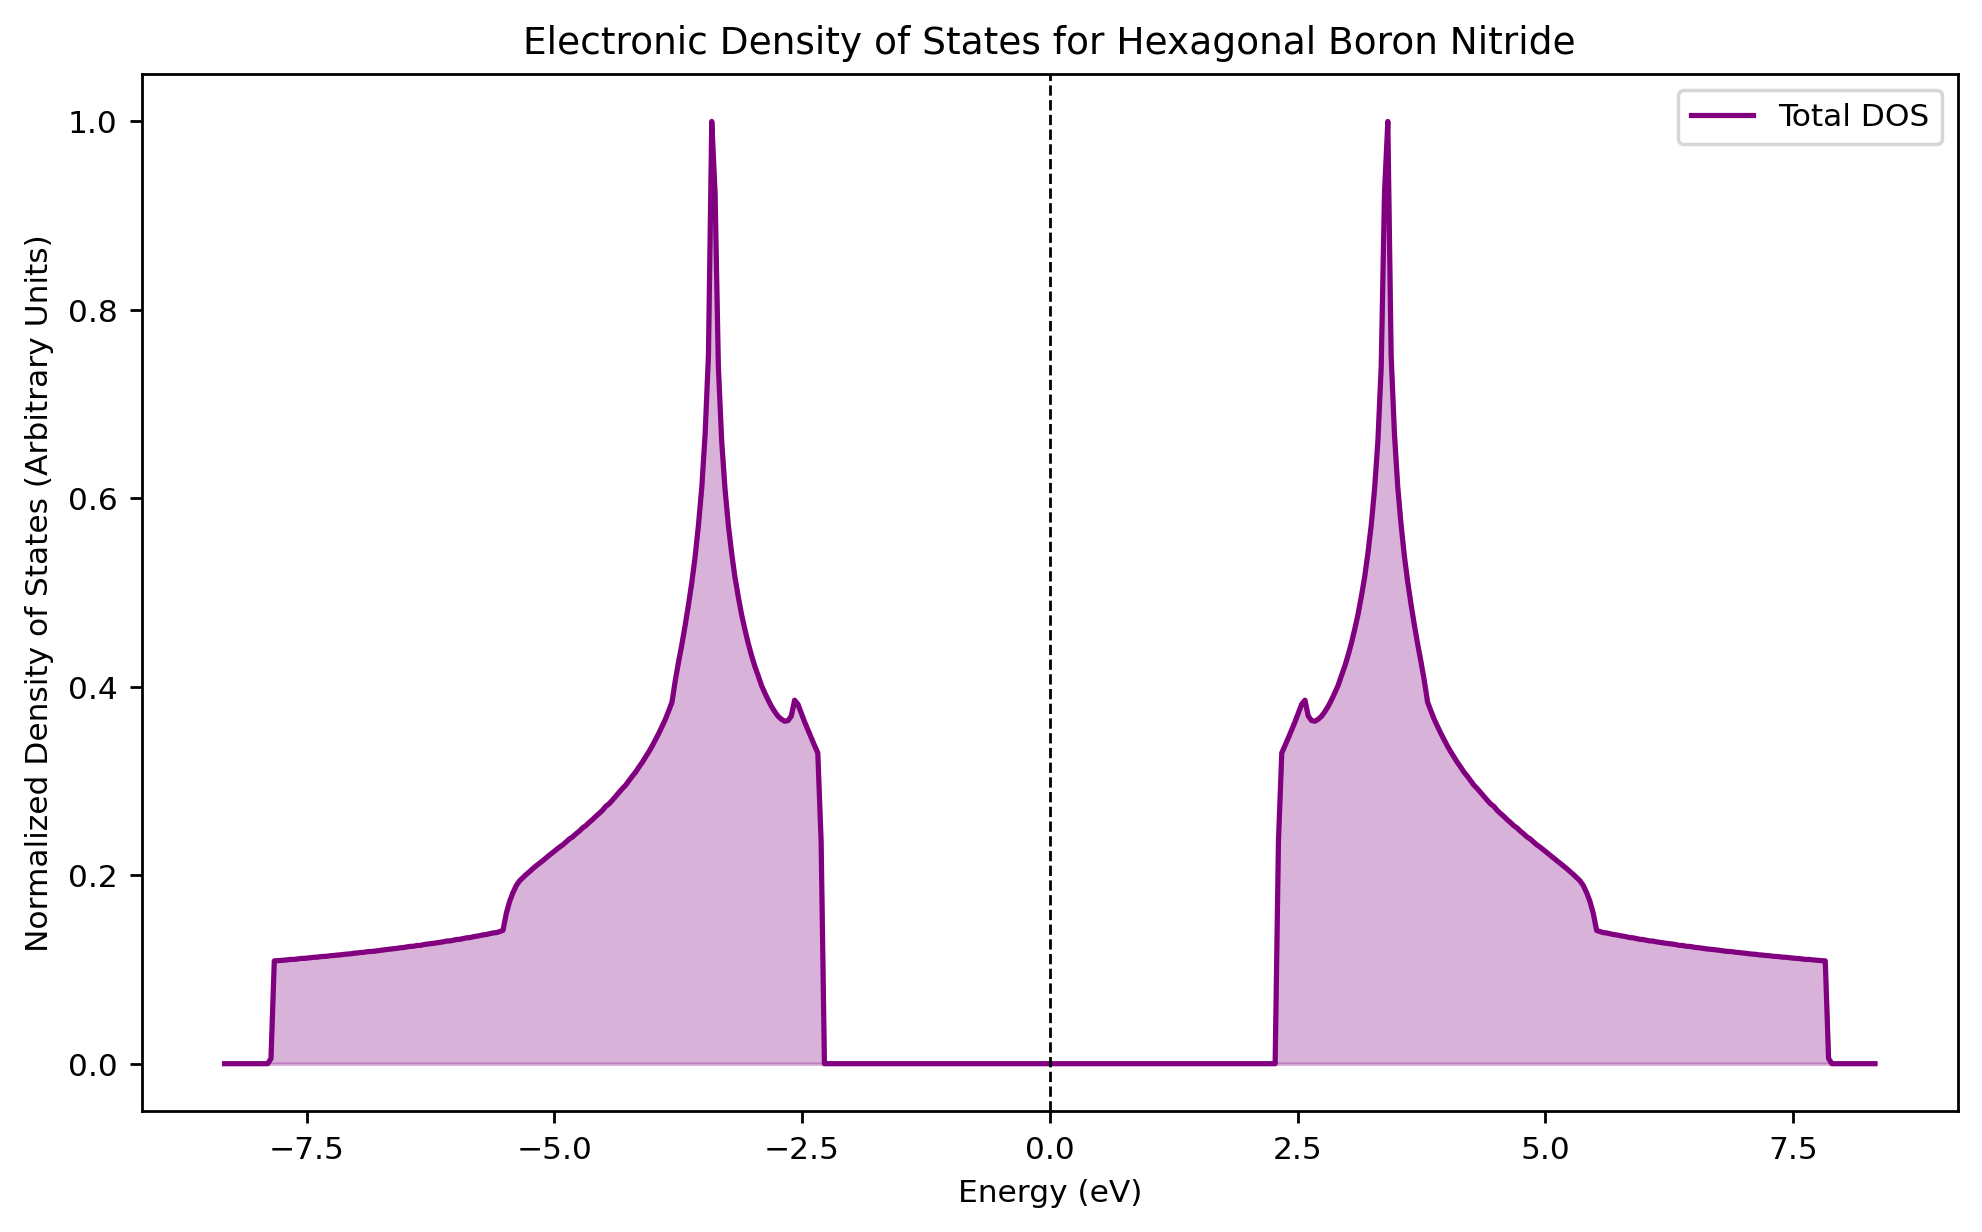

In [4]:
"""
Computes and visualizes the electronic density of states for hexagonal boron nitride.

This script evaluates the tight binding energy dispersion over a massively dense
two dimensional reciprocal space grid utilizing GPU acceleration via CuPy.
The algorithm subsequently bins the computed energy eigenvalues to resolve
the density of states and visualizes the distribution using Matplotlib.
"""

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONTROL KNOBS
# =============================================================================
T_HOPPING: float = 2.5          # eV, nearest neighbor hopping energy
DELTA_ONSITE: float = 4.6       # eV, on site energy difference between B and N
A_LATTICE: float = 2.50         # Angstroms, lattice constant for hexagonal boron nitride
K_RESOLUTION: int = 4000        # Grid resolution yielding K_RESOLUTION squared points
ENERGY_BINS: int = 500          # Number of discrete bins for the histogram
PLOT_DPI: int = 250             # DPI for Colab inline rendering

# =============================================================================
# Apply rendering preferences
plt.rcParams['figure.dpi'] = PLOT_DPI
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'

def calc_energy_gpu(k_x: cp.ndarray, k_y: cp.ndarray, t: float, delta: float, a: float) -> cp.ndarray:
    """
    Calculates the tight binding energy dispersion utilizing GPU acceleration.

    Args:
        k_x (cp.ndarray): Wavevector array in the x direction (CuPy array).
        k_y (cp.ndarray): Wavevector array in the y direction (CuPy array).
        t (float): Nearest neighbor hopping energy (eV).
        delta (float): On site energy difference between sublattices (eV).
        a (float): Lattice constant (Angstroms).

    Returns:
        cp.ndarray: Evaluated energy eigenvalues (conduction band) residing on the GPU.
    """
    # Evaluate the geometric structure factor modulus squared
    term1 = 4.0 * cp.cos(cp.sqrt(3.0) * k_x * a / 2.0) * cp.cos(k_y * a / 2.0)
    term2 = 4.0 * cp.cos(k_y * a / 2.0)**2
    f_k_squared = 1.0 + term1 + term2

    # Calculate the positive root representing the conduction band
    energy = cp.sqrt((delta / 2.0)**2 + (t**2) * f_k_squared)
    return energy

def render_density_of_states() -> None:
    """
    Computes the energy histogram and renders the density of states plot.
    """
    # Define Brillouin zone volumetric bounds
    k_extent = 4.0 * cp.pi / (3.0 * A_LATTICE)

    # Generate dense arrays on the GPU
    kx_range = cp.linspace(-k_extent, k_extent, K_RESOLUTION)
    ky_range = cp.linspace(-k_extent, k_extent, K_RESOLUTION)

    # Create the meshgrid
    kx_mesh, ky_mesh = cp.meshgrid(kx_range, ky_range)

    # Flatten the arrays for vectorized processing
    kx_flat = kx_mesh.flatten()
    ky_flat = ky_mesh.flatten()

    # Compute continuous band energies on the GPU
    e_conduction = calc_energy_gpu(kx_flat, ky_flat, T_HOPPING, DELTA_ONSITE, A_LATTICE)
    e_valence = -e_conduction

    # Determine absolute maximum energy to establish uniform histogram boundaries
    max_energy = float(cp.max(e_conduction))
    bin_edges = cp.linspace(-max_energy - 0.5, max_energy + 0.5, ENERGY_BINS)

    # Compute the histograms on the GPU
    dos_conduction, _ = cp.histogram(e_conduction, bins=bin_edges)
    dos_valence, _ = cp.histogram(e_valence, bins=bin_edges)

    # Aggregate the total density of states
    total_dos = dos_conduction + dos_valence

    # Transfer the computed arrays back to the CPU for visualization
    bin_centers_cpu = cp.asnumpy(bin_edges[:-1] + cp.diff(bin_edges) / 2.0)
    total_dos_cpu = cp.asnumpy(total_dos)

    # Normalize the density of states
    total_dos_cpu = total_dos_cpu / np.max(total_dos_cpu)

    # Render the visualization
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(bin_centers_cpu, total_dos_cpu, color='purple', linewidth=1.5, label='Total DOS')
    ax.fill_between(bin_centers_cpu, 0, total_dos_cpu, color='purple', alpha=0.3)

    # Apply precise stylistic formatting
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Normalized Density of States (Arbitrary Units)")
    ax.set_title("Electronic Density of States for Hexagonal Boron Nitride")
    ax.legend()
    ax.grid(False)

    # Adjust layout and display without saving
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_density_of_states()

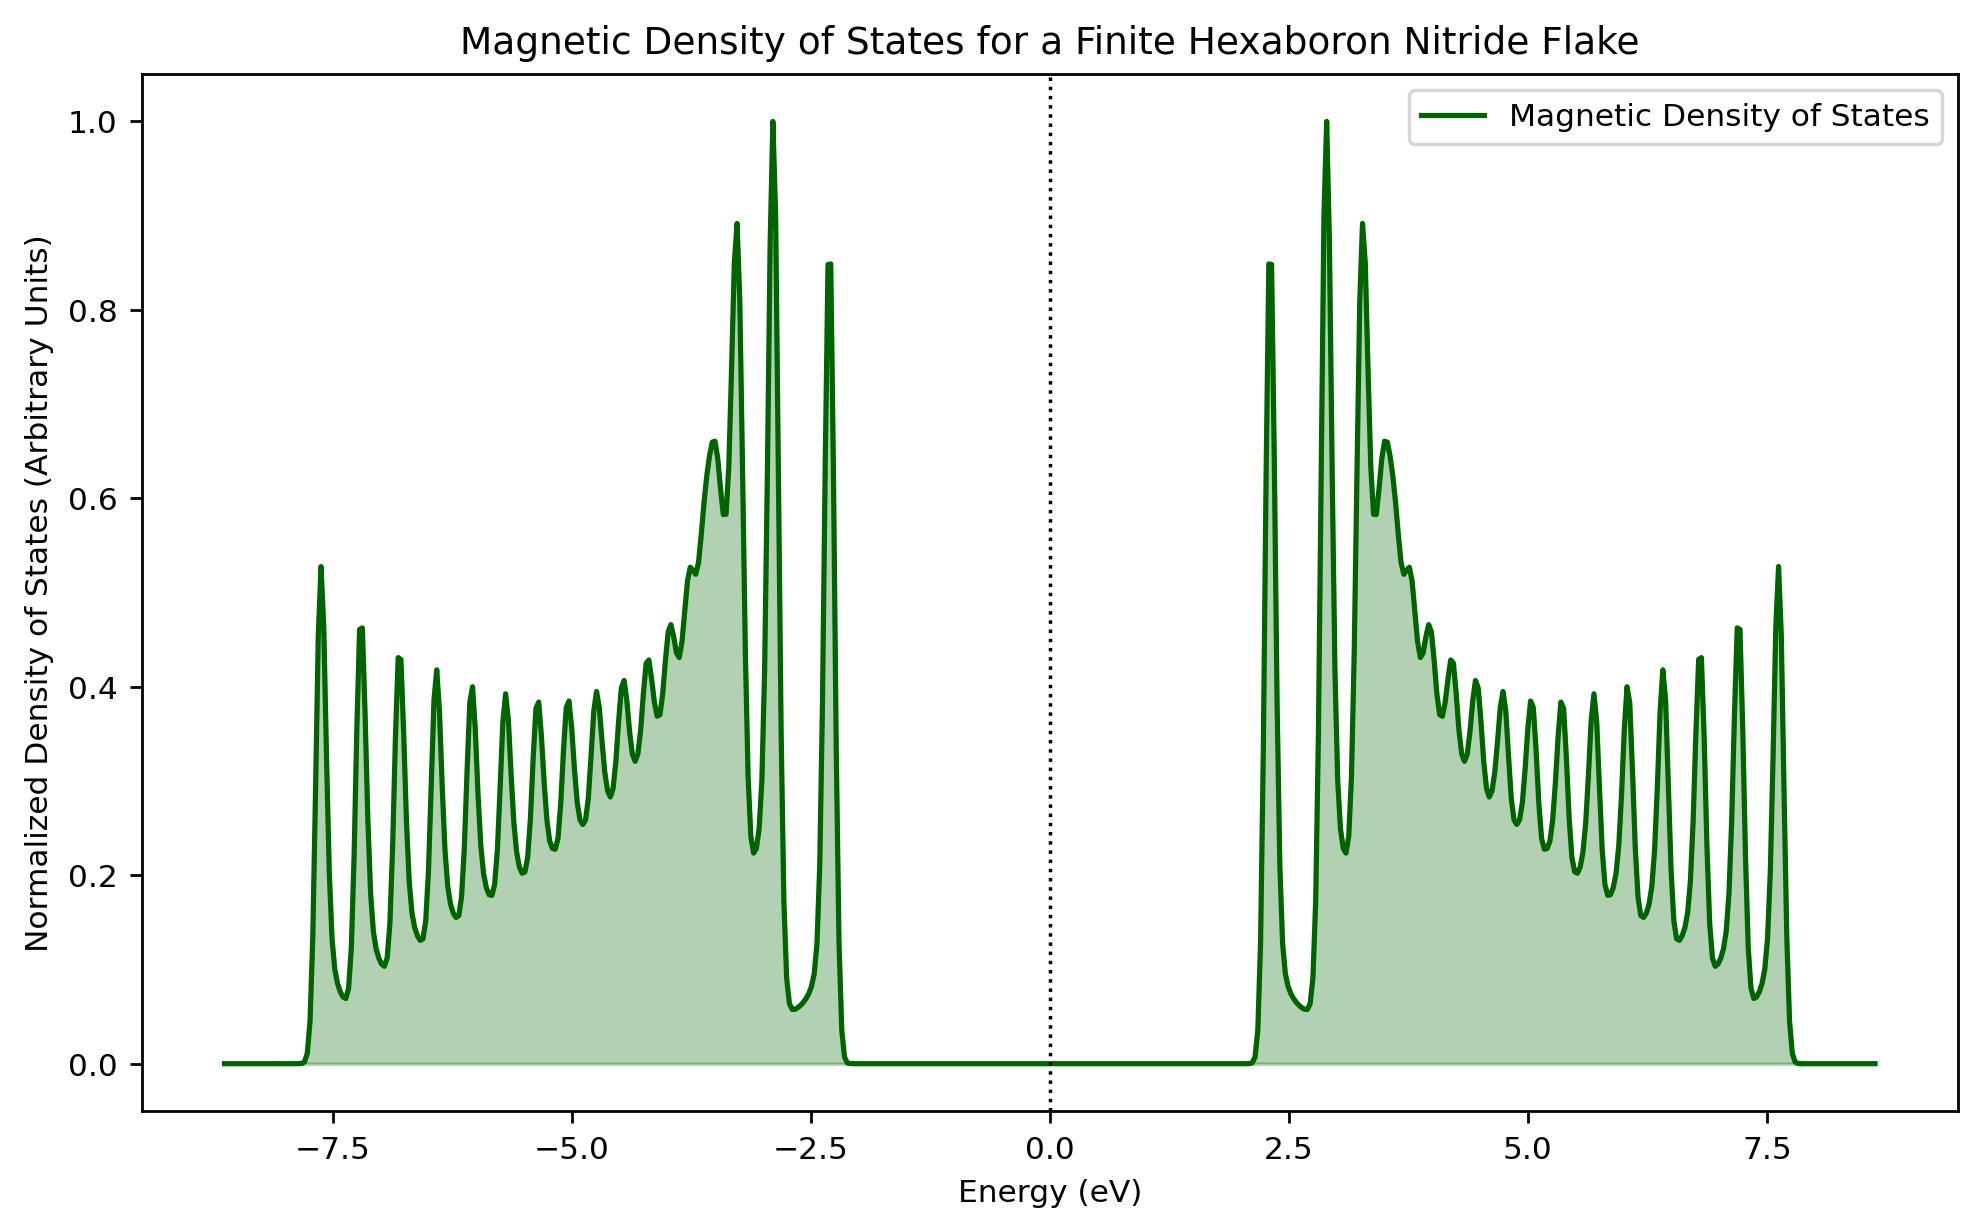

In [5]:
"""
Computes and visualizes the electronic density of states for a finite hexaboron nitride flake in a magnetic field.

This script constructs a real space tight binding Hamiltonian for a rectangular
hexaboron nitride lattice incorporating a Peierls phase substitution. The
algorithm utilizes GPU acceleration to diagonalize the complex Hermitian
matrix and subsequently applies a Gaussian broadening function to resolve
the continuous density of states.
"""

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONTROL KNOBS
# =============================================================================
T_HOPPING: float = 2.5          # eV, nearest neighbor hopping energy
DELTA_ONSITE: float = 4.6       # eV, on site energy difference between Boron and Nitrogen
A_BOND: float = 1.44            # Angstroms, interatomic bond length
FLAKE_WIDTH: float = 60.0       # Angstroms, spatial width of the simulated rectangular flake
FLAKE_HEIGHT: float = 60.0      # Angstroms, spatial height of the simulated rectangular flake
FLUX_RATIO: float = 0.05        # Normalized magnetic flux per unit cell (alpha)
BROADENING_SIGMA: float = 0.05  # eV, Gaussian broadening standard deviation
ENERGY_BINS: int = 600          # Number of discrete points for the energy axis
PLOT_DPI: int = 250             # DPI for Colab inline rendering

# =============================================================================
# Apply rendering preferences
plt.rcParams['figure.dpi'] = PLOT_DPI
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'

def generate_flake_coordinates(width: float, height: float, a_cc: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generates the real space atomic coordinates for a finite rectangular hexaboron nitride flake.

    Args:
        width (float): The target physical width of the flake (Angstroms).
        height (float): The target physical height of the flake (Angstroms).
        a_cc (float): The interatomic bond distance (Angstroms).

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: X coordinates, Y coordinates, and atomic site identities
                                                   (1 for Boron, -1 for Nitrogen).
    """
    x_list = []
    y_list = []
    site_list = []

    # Calculate sufficient integer bounds to cover the requested physical dimensions
    n_max = int(max(width, height) / a_cc) + 5

    for n1 in range(-n_max, n_max):
        for n2 in range(-n_max, n_max):
            # Evaluate coordinates for the Boron site (Sublattice A)
            x_a = a_cc * (1.5 * n1 + 1.5 * n2)
            y_a = a_cc * (np.sqrt(3.0) / 2.0 * n1 - np.sqrt(3.0) / 2.0 * n2)

            if 0.0 <= x_a <= width and 0.0 <= y_a <= height:
                x_list.append(x_a)
                y_list.append(y_a)
                site_list.append(1)

            # Evaluate coordinates for the Nitrogen site (Sublattice B)
            x_b = x_a + a_cc
            y_b = y_a

            if 0.0 <= x_b <= width and 0.0 <= y_b <= height:
                x_list.append(x_b)
                y_list.append(y_b)
                site_list.append(-1)

    return np.array(x_list), np.array(y_list), np.array(site_list)

def construct_magnetic_hamiltonian(x: np.ndarray, y: np.ndarray, sites: np.ndarray,
                                   t: float, delta: float, a_cc: float, alpha: float) -> cp.ndarray:
    """
    Constructs the complex Hermitian tight binding Hamiltonian matrix incorporating the Peierls phase.

    Args:
        x (np.ndarray): Array of X atomic coordinates.
        y (np.ndarray): Array of Y atomic coordinates.
        sites (np.ndarray): Array of atomic identities.
        t (float): Hopping parameter (eV).
        delta (float): On site energy differential (eV).
        a_cc (float): Bond length (Angstroms).
        alpha (float): Magnetic flux ratio per hexagon.

    Returns:
        cp.ndarray: The dense complex Hamiltonian matrix residing on the GPU.
    """
    num_atoms = len(x)

    # Initialize the Hamiltonian on the GPU
    hamiltonian = cp.zeros((num_atoms, num_atoms), dtype=cp.complex128)

    # Transfer spatial coordinates to the GPU for accelerated distance calculations
    x_gpu = cp.asarray(x)
    y_gpu = cp.asarray(y)
    sites_gpu = cp.asarray(sites)

    # Assign diagonal on site energies
    diag_indices = cp.arange(num_atoms)
    hamiltonian[diag_indices, diag_indices] = (delta / 2.0) * sites_gpu

    # Compute pairwise spatial distances utilizing broadcasting
    dx = x_gpu[:, None] - x_gpu[None, :]
    dy = y_gpu[:, None] - y_gpu[None, :]
    distance = cp.sqrt(dx**2 + dy**2)

    # Isolate nearest neighbors utilizing a slight numerical tolerance
    neighbor_mask = (distance > 0.1 * a_cc) & (distance < 1.1 * a_cc)

    # Compute the Peierls phase factor assuming a Landau gauge
    # The physical area of a single hexagon is (3 * sqrt(3) / 2) * a_cc^2
    hexagon_area = 1.5 * cp.sqrt(3.0) * (a_cc ** 2)

    # Phase integral approximation evaluating the Landau vector potential
    phase = cp.pi * (alpha / hexagon_area) * (x_gpu[:, None] + x_gpu[None, :]) * (y_gpu[None, :] - y_gpu[:, None])

    # Construct the complex hopping matrix elements
    hopping_matrix = t * cp.exp(1j * phase)

    # Apply the nearest neighbor connectivity mask
    hamiltonian[neighbor_mask] = hopping_matrix[neighbor_mask]

    return hamiltonian

def render_magnetic_density_of_states() -> None:
    """
    Coordinates the geometric generation, GPU diagonalization, and subsequent inline visualization.
    """
    # Generate the finite flake lattice configuration
    x_coords, y_coords, sites = generate_flake_coordinates(FLAKE_WIDTH, FLAKE_HEIGHT, A_BOND)

    # Construct the Hamiltonian matrix on the GPU
    hamiltonian_gpu = construct_magnetic_hamiltonian(x_coords, y_coords, sites,
                                                     T_HOPPING, DELTA_ONSITE, A_BOND, FLUX_RATIO)

    # Execute the Hermitian eigendecomposition
    eigenvalues_gpu = cp.linalg.eigvalsh(hamiltonian_gpu)

    # Define a uniform continuous energy axis spanning the relevant energetic spectrum
    max_energy = float(cp.max(cp.abs(eigenvalues_gpu))) + 1.0
    energy_axis = cp.linspace(-max_energy, max_energy, ENERGY_BINS)

    # Broadcast the Gaussian broadening function over the discrete eigenvalues
    energy_diff = energy_axis[:, None] - eigenvalues_gpu[None, :]
    gaussian_matrix = cp.exp(-0.5 * (energy_diff / BROADENING_SIGMA)**2)

    # Aggregate the individual broadened peaks into a continuous spectrum
    dos_gpu = cp.sum(gaussian_matrix, axis=1) / (cp.sqrt(2.0 * cp.pi) * BROADENING_SIGMA * len(eigenvalues_gpu))

    # Normalize the total density of states
    dos_gpu = dos_gpu / cp.max(dos_gpu)

    # Transfer the finalized numerical arrays back to the central processing unit
    energy_cpu = cp.asnumpy(energy_axis)
    dos_cpu = cp.asnumpy(dos_gpu)

    # Render the continuous profile using Matplotlib
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(energy_cpu, dos_cpu, color='darkgreen', linewidth=1.5, label='Magnetic Density of States')
    ax.fill_between(energy_cpu, 0, dos_cpu, color='darkgreen', alpha=0.3)

    # Apply strict typographical and graphical formatting
    ax.axvline(0, color='k', linestyle=':', linewidth=1.0)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Normalized Density of States (Arbitrary Units)")
    ax.set_title("Magnetic Density of States for a Finite Hexaboron Nitride Flake")
    ax.legend()
    ax.grid(False)

    # Finalize the display directly in the notebook environment
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_magnetic_density_of_states()